# Car Instance Segmentation + Live CCTV Count

Fine-tune YOLOv8n-seg pada dataset custom "car-detection" (Roboflow), lalu pakai model hasil fine-tuning itu untuk hitung mobil real-time dari feed CCTV publik Kota Jogja (Malioboro / Titik Nol KM).

> **Catatan:** notebook ini sudah diperbaiki dari draf sebelumnya — model hasil training sekarang benar-benar dipakai untuk inference (sebelumnya notebook diam-diam beralih ke model pretrained COCO yang belum di-fine-tune). API key Roboflow juga sudah tidak di-hardcode.

In [1]:
!nvidia-smi

Sun Sep 20 09:57:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics roboflow opencv-python pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.0 MB/s eta 0:00:00


## 1. Dataset — Roboflow

API key diambil dari Colab Secrets (`ROBOFLOW_API_KEY`), fallback ke input tersembunyi kalau belum diset. **Jangan hardcode key di cell.**

Balik ke dataset single-class `car-detection-hguc8` (domain CCTV Jogja, recall mobil paling baik dari semua percobaan). Masalah "motor kadang kebaca car" ditangani lewat filter tambahan di live-stream (Section 5), bukan lewat kelas baru — setelah 2 percobaan retrain 2-kelas sama-sama gagal generalisasi (dataset generik: 0 deteksi di CCTV asli; dataset gabungan CCTV: motorcycle instance-nya cuma 22, terlalu sedikit).

In [4]:
from roboflow import Roboflow

try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
except Exception:
    ROBOFLOW_API_KEY = None

if not ROBOFLOW_API_KEY:
    from getpass import getpass
    ROBOFLOW_API_KEY = getpass('Roboflow API Key: ')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("kitaro").project("car-detection-hguc8")
version = project.version(2)
dataset = version.download("yolov8")

print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-detection-2 in yolov8:: 100%|██████████| 463/463 [00:00<00:00, 8232.53it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Dataset location: /content/car-detection-2


## 2. Training — Fine-tune YOLOv8s-seg

Model dan hasil training (`best.pt`) inilah yang akan dipakai di semua cell inference/live-stream berikutnya — bukan pretrained COCO. Weight disalin ke Google Drive setelah training supaya tidak hilang kalau runtime Colab terputus.

**Kalau kamu sudah pernah training model single-class ini sebelumnya (folder `car_instance_segmentation` di Drive), cell load-model di Section 3 akan otomatis pakai itu tanpa perlu training ulang — cell ini boleh di-skip.**

In [5]:
from ultralytics import YOLO
import os, glob, shutil

data_yaml = os.path.join(dataset.location, 'data.yaml')

model = YOLO('yolov8s-seg.pt')

epochs = 30
batch_size = 32
img_size = 640
run_name = 'car_segmentation'

train_results = model.train(
    data=data_yaml,
    epochs=epochs,
    batch=batch_size,
    imgsz=img_size,
    name=run_name,
    # No `project=` override here on purpose: Ultralytics already defaults to a
    # runs/segment/<n> path for segmentation tasks, and passing project='runs/segment'
    # explicitly caused it to nest as runs/segment/runs/segment/<n> in an earlier version.
)

val_metrics = model.val()
print(val_metrics)

# Persist the trained weights to Google Drive so they survive a Colab disconnect.
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

drive_dir = '/content/drive/MyDrive/car_instance_segmentation'
os.makedirs(drive_dir, exist_ok=True)

local_candidates = sorted(
    glob.glob(f'runs/segment/{run_name}*/weights/best.pt'),
    key=os.path.getmtime,
)
assert local_candidates, "best.pt tidak ditemukan setelah training — cek log training di atas."
local_best = local_candidates[-1]

drive_best = os.path.join(drive_dir, 'best.pt')
shutil.copy(local_best, drive_best)
print("Trained weights copied to Drive:", drive_best)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car-detection-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_segmentation, nbs=64,

## 3. Load Model Hasil Fine-Tuning

Load dari Google Drive (persisten lintas sesi Colab) kalau ada, kalau tidak fallback cari file lokal terbaru lewat glob pada prefix nama run — bukan path hardcode, karena Ultralytics menambah angka di nama folder tiap rerun.

In [6]:
run_name = 'car_segmentation'
drive_best = '/content/drive/MyDrive/car_instance_segmentation/best.pt'

local_candidates = sorted(
    glob.glob(f'runs/segment/{run_name}*/weights/best.pt'),
    key=os.path.getmtime,
)

if os.path.exists(drive_best):
    best_weights = drive_best
elif local_candidates:
    best_weights = local_candidates[-1]
else:
    best_weights = None

assert best_weights and os.path.exists(best_weights), (
    "Weight tidak ditemukan di Drive maupun folder runs lokal — pastikan training di atas "
    f"sudah selesai, atau upload best.pt manual ke {drive_best}"
)

trained_model = YOLO(best_weights)
print("Loaded fine-tuned model:", best_weights)

Loaded fine-tuned model: /content/drive/MyDrive/car_instance_segmentation/best.pt


## 4. Test Inference pada Sample Image

In [7]:
import glob

test_images = sorted(
    glob.glob(os.path.join(dataset.location, 'test', 'images', '*.jpg')) +
    glob.glob(os.path.join(dataset.location, 'test', 'images', '*.png'))
)  # *.png ditambah karena gambar dari CCTV Bandung berupa screenshot PNG
assert test_images, "Tidak ada gambar test ditemukan — cek struktur folder dataset."
sample_image_path = test_images[0]
print("Sample image:", sample_image_path)

Sample image: /content/car-detection-2/test/images/CCTV_titik-nol-KM-jogja_mp4-0017_jpg.rf.e6818a4586a494a80ee4dfd6288df5a4.jpg


Cars detected: 9


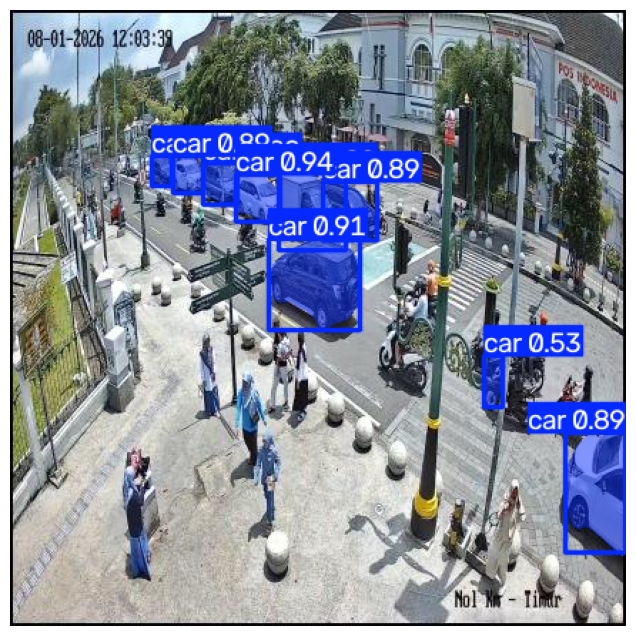

In [8]:
import cv2, matplotlib.pyplot as plt

def segment(path, conf=0.5):
    results = trained_model.predict(source=path, conf=conf, verbose=False)
    r = results[0]
    masks = r.masks

    print(f"Cars detected: {len(masks) if masks is not None else 0}")

    im = r.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

segment(sample_image_path)

## 5. Live-Stream CCTV Publik (ATCS Sugeng Jeroni, Jogja)

Class `LiveStreamSegmenter`, single-class ("car"). Dua lapis filter untuk buang deteksi nyasar (motor/helm yang kebaca "car"):
1. **Ukuran kotak minimum** (`MIN_BOX_AREA_PX`) — buang kotak yang terlalu kecil buat jadi mobil
2. **Rasio isi mask** (`MIN_FILL_RATIO`, baru) — mobil dari sudut CCTV ini bentuknya padat mengisi hampir seluruh kotaknya; motor+pengendara jauh lebih "berlubang" (banyak ruang kosong di sela rangka motor dan orangnya). Filter ini dihitung dari mask asli, jadi cuma aktif kalau `r.masks` tersedia — makanya `track()` diganti balik ke `predict()` supaya mask selalu konsisten muncul (sebelumnya `track()` kadang balikin `masks=None` walau deteksi valid).

In [9]:
import time
from pathlib import Path
from collections import deque
from datetime import datetime
import numpy as np
from IPython.display import clear_output


class LiveStreamSegmenter:
    """Live car-counting dari M3U8 CCTV, pakai model hasil fine-tuning. No window display — cocok untuk Jupyter/Colab."""

    def __init__(self, model, min_box_area_px=6000, min_fill_ratio=0.35):
        self.model = model
        self.MIN_BOX_AREA_PX = min_box_area_px
        self.MIN_FILL_RATIO = min_fill_ratio
        self.frame_count = 0
        self.car_counts = deque(maxlen=300)
        self.fps_list = deque(maxlen=300)
        self.start_time = None
        self.video_writer = None
        self.output_dir = Path('stream_output')
        self.output_dir.mkdir(exist_ok=True)

    def stream_m3u8(self, m3u8_url, conf=0.5, max_frames=None,
                     record=False, output_fps=15, display_interval=30, label=None):
        self.label = label
        header = (
            f"Live stream: {m3u8_url}\n"
            f"Confidence: {conf*100:.0f}%\n"
            f"Recording: {'Yes' if record else 'No'}\n"
            f"Max frames: {max_frames if max_frames else 'Unlimited'}"
        )
        print(header)
        print("Connecting...")

        cap = cv2.VideoCapture(m3u8_url)
        if not cap.isOpened():
            print("Cannot open stream.")
            return

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or 1280
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or 720
        print(f"Stream: {width}x{height}")

        output_file = None
        if record:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            prefix = f"{label}_" if label else ""
            output_file = self.output_dir / f"stream_{prefix}{timestamp}.mp4"
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            self.video_writer = cv2.VideoWriter(str(output_file), fourcc, output_fps, (width, height))
            print(f"Recording to: {output_file}")

        self.start_time = time.time()
        last_display = 0

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    print("Stream ended or disconnected.")
                    break

                self.frame_count += 1
                if max_frames and self.frame_count > max_frames:
                    break

                t0 = time.time()
                # predict() (bukan track()) -- masks perlu selalu konsisten tersedia untuk
                # filter rasio-isi di bawah; track() kadang balikin masks=None walau
                # deteksinya valid, yang sebelumnya juga bikin stats salah hitung.
                results = self.model.predict(source=frame, conf=conf, verbose=False)
                r = results[0]

                if r.boxes is not None and len(r.boxes) > 0:
                    xyxy = r.boxes.xyxy.cpu().numpy()
                    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                    keep = areas >= self.MIN_BOX_AREA_PX

                    # Filter rasio-isi mask: mobil solid mengisi hampir seluruh kotaknya;
                    # motor+pengendara jauh lebih "berlubang". Cuma dihitung kalau mask
                    # tersedia dan jumlahnya cocok dengan jumlah box.
                    if r.masks is not None and len(r.masks) == len(r.boxes):
                        mask_h, mask_w = r.masks.data.shape[-2:]
                        frame_h, frame_w = frame.shape[:2]
                        sx, sy = mask_w / frame_w, mask_h / frame_h
                        mask_areas = r.masks.data.sum(dim=(1, 2)).cpu().numpy()
                        fill_ratios = np.array([
                            mask_areas[i] / max((x2 - x1) * sx * (y2 - y1) * sy, 1e-6)
                            for i, (x1, y1, x2, y2) in enumerate(xyxy)
                        ])
                        keep = keep & (fill_ratios >= self.MIN_FILL_RATIO)

                    r = r[keep]

                elapsed_frame = time.time() - t0
                self.fps_list.append(1 / elapsed_frame if elapsed_frame > 0 else 0)

                num_cars = len(r.boxes) if r.boxes is not None else 0
                self.car_counts.append(num_cars)

                if record and self.video_writer:
                    self.video_writer.write(r.plot())

                if self.frame_count - last_display >= display_interval:
                    clear_output(wait=True)
                    print(header)
                    if output_file:
                        print(f"Recording to: {output_file}")
                    avg_fps = np.mean(self.fps_list) if self.fps_list else 0
                    avg_cars = np.mean(self.car_counts) if self.car_counts else 0
                    elapsed = time.time() - self.start_time
                    print(f"Frame {self.frame_count} | Cars: {num_cars} (avg {avg_cars:.1f}) | FPS: {avg_fps:.1f} | {elapsed:.0f}s")
                    last_display = self.frame_count

        except KeyboardInterrupt:
            print("Stopped by user.")
        finally:
            cap.release()
            if self.video_writer:
                self.video_writer.release()
            self._save_stats()
            if output_file:
                print("Video saved to:", output_file)

    def _save_stats(self):
        if not self.start_time:
            return
        elapsed = time.time() - self.start_time
        stats = {
            'timestamp': datetime.now().isoformat(),
            'total_frames': self.frame_count,
            'duration_seconds': elapsed,
            'average_fps': self.frame_count / elapsed if elapsed > 0 else 0,
            'average_cars': float(np.mean(self.car_counts)) if self.car_counts else 0,
            'max_cars': int(max(self.car_counts)) if self.car_counts else 0,
            'min_cars': int(min(self.car_counts)) if self.car_counts else 0,
        }
        prefix = f"{getattr(self, 'label', None)}_" if getattr(self, 'label', None) else ""
        stats_file = self.output_dir / f"stats_{prefix}{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        with open(stats_file, 'w') as f:
            json.dump(stats, f, indent=2)
        print("Stats:", stats)
        print("Saved to:", stats_file)

In [10]:
import json  # used by _save_stats above

# Difokuskan ke 1 kamera: Sugeng Jeroni — sudut paling dekat/jelas dari 3 kamera
# yang dicoba, jadi paling representatif untuk menilai akurasi model.
segmenter = LiveStreamSegmenter(model=trained_model)
segmenter.stream_m3u8(
    m3u8_url='https://cctvjss.jogjakota.go.id/atcs/ATCS_Lampu_Merah_SugengJeroni1.stream/playlist.m3u8',
    conf=0.62,  # nilai final pilihan Shaka setelah uji coba sendiri (0.5-0.65) --
                # titik tengah antara terlalu longgar (motor salah kebaca car) dan
                # terlalu ketat (mobil asli confidence pas-pasan ikut kebuang)
    max_frames=600,
    record=True,
    label='Sugeng_Jeroni',
)

Live stream: https://cctvjss.jogjakota.go.id/atcs/ATCS_Lampu_Merah_SugengJeroni1.stream/playlist.m3u8
Confidence: 62%
Recording: Yes
Max frames: 600
Recording to: stream_output/stream_Sugeng_Jeroni_20260920_095953.mp4
Frame 600 | Cars: 0 (avg 0.7) | FPS: 77.7 | 26s
Stats: {'timestamp': '2026-09-20T10:00:19.528154', 'total_frames': 601, 'duration_seconds': 25.71844792366028, 'average_fps': 23.36843972015497, 'average_cars': 0.6633333333333333, 'max_cars': 3, 'min_cars': 0}
Saved to: stream_output/stats_Sugeng_Jeroni_20260920_100019.json
Video saved to: stream_output/stream_Sugeng_Jeroni_20260920_095953.mp4


## 6. Catatan Verifikasi (isi setelah run Colab)

- [ ] Load model: cek print "Loaded fine-tuned model" — pastikan path-nya `car_instance_segmentation/best.pt` (single-class)
- [ ] Live-stream Sugeng Jeroni diuji dan `stream_output/stream_*.mp4` + `stats_*.json` tersimpan
- [x] `conf=0.62` — nilai final pilihan Shaka setelah uji coba sendiri, dianggap titik seimbang paling pas

**Keterbatasan final yang diketahui (jangan disembunyikan di blog/README):**
- Model tetap 1 kelas ("car") — sesekali motor/pesepeda dengan siluet besar/padat masih bisa salah kebaca "car", terutama pada confidence di bawah ~0.62. `conf=0.62` adalah titik seimbang pilihan Shaka sendiri (precision-recall tradeoff) setelah membandingkan langsung 0.5 vs 0.6 vs 0.65 di footage yang sama — bukan angka sempurna, tapi kompromi yang paling masuk akal dari beberapa yang sudah diuji
- Filter ukuran kotak (`MIN_BOX_AREA_PX=6000`) dan rasio-isi mask (`MIN_FILL_RATIO=0.35`) membantu menyaring sebagian kasus (helm, motor+beban) tanpa memengaruhi recall mobil, tapi tidak menghilangkan total risiko
- Mobil warna gelap/dengan silau kuat kadang tidak terdeteksi sama sekali (bukan soal threshold — sinyalnya memang lemah dari awal), kemungkinan karena variasi warna/pencahayaan kurang terwakili di 201 foto training
- Percobaan retrain 2-kelas (car+motorcycle) dicoba 2x dan gagal generalisasi (dataset generik: 0 deteksi di CCTV asli; dataset gabungan CCTV: motorcycle instance cuma 22, terlalu sedikit) — didokumentasikan sebagai bagian proses eksplorasi, bukan disembunyikan